# Random Forest Predicting Fuel Type

In [1]:
import pandas as pd # For data manipulation
import numpy as np # For numerical operations
import re # For regular expressions
import matplotlib.pyplot as plt # For plotting
from sklearn.model_selection import train_test_split # For splitting the dataset
from sklearn.metrics import classification_report, confusion_matrix # For model evaluation
from sklearn.ensemble import RandomForestClassifier # For the Random Forest model

# Load the dataset
df = pd.read_excel('CarsDataset.xlsx')

# Clean the Dataset

In [2]:
# Drop rows with NaN in X

# Extract the first number from a string, handling commas and spaces
def extract_first_number(x):
    nums = re.findall(r'\d+', str(x)) # extract all numbers
    for n in nums:
        n_clean = n.replace(',', ''). replace(' ', '') # clean the number
        if n_clean and n_clean != '.': 
            try: 
                return float(n_clean) # convert to float
            except:
                continue
    return np.nan

# Extract the average of two numbers
def extract_average_range_safe(x):
    nums = [n for n in re.findall(r"[\d,.]+", str(x)) if n.replace(',', '').replace('.', '').strip() != ""] # extract numbers, ignoring empty strings
    try:
        if len(nums) == 2: 
            v1 = float(nums[0].replace(',', '').replace(' ', '')) 
            v2 = float(nums[1].replace(',', '').replace(' ', '')) 
            return (v1 + v2) / 2 
        elif len(nums) == 1: 
            return float(nums[0].replace(',', '').replace(' ', '')) 
        else:
            return np.nan 
    except:
        return np.nan 

In [3]:
# Extract only numeric values from the relevant columns
df_clean = df.copy()
df_clean['Engine_CC']      = df_clean['CC/Battery Capacity'].apply(extract_first_number)
df_clean['HorsePower']     = df_clean['HorsePower'].apply(extract_average_range_safe)
df_clean['Max_Speed_kmh']  = df_clean['Total Speed'].apply(extract_first_number)
df_clean['Torque_Nm']      = df_clean['Torque'].apply(extract_average_range_safe) 
df_clean['Zero_100_Sec']   = df_clean['Performance(0 - 100 )KM/H'].apply(extract_first_number)

# Condense Fuel Types into Relevant categories
fuel_mapping = {
    'Petrol': 'Petrol',
    'Diesel': 'Diesel',
    'Electric': 'Electric',
    'Hybrid': 'Hybrid',
    'Petrol/Hybrid': 'Hybrid',
    'Hybrid (Petrol)': 'Hybrid',
    'Plug-in Hybrid': 'Hybrid',
    'Hybrid / Plug-in': 'Hybrid',
    'Gas / Hybrid': 'Hybrid',
    'Petrol/Diesel': 'Petrol/Diesel',
    'CNG/Petrol': 'Petrol',
    'Hybrid (Gas + Electric)': 'Hybrid',
    'Hybrid / Electric': 'Hybrid',
    'Hybrid/Electric': 'Hybrid',
    'Hybrid/Petrol': 'Hybrid',
    'Petrol/AWD': 'Petrol',
    'Petrol/EV': 'Hybrid',
    'plug in hyrbrid': 'Hybrid',
    'Petrol, Diesel': 'Petrol/Diesel',
    'Petrol, Hybrid': 'Hybrid',
    'Diesel / Petrol': 'Petrol/Diesel',
    'Diesel/Petrol' : 'Petrol/Diesel',
    'Hydrogen': 'Hydrogen',
}

# Map the fuel types to the new categories
df_clean['Fuel Types'] = df_clean['Fuel Types'].replace(fuel_mapping)

# Select features and target variable
X = df_clean[['Engine_CC', 'HorsePower', 'Max_Speed_kmh', 'Torque_Nm', 'Zero_100_Sec']] # Features
y = df_clean['Fuel Types'] # Target variable

# Drop rows with NaN in X
Xy = pd.concat([X, y], axis=1).dropna()
X_clean = Xy[['Engine_CC', 'Max_Speed_kmh', 'Torque_Nm', 'Zero_100_Sec', 'HorsePower']]
y = Xy['Fuel Types']

# Convert y to category (no need to rename categories by integer code)
y = y.astype('category')

# Model

In [4]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_clean, y, test_size = 0.2, random_state = 42)

# Create and train the Random Forest model
rf_model = RandomForestClassifier(n_estimators = 100, random_state = 42)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[ 13   0   0   5   0]
 [  0  21   0   1   0]
 [  0   0  13  14   1]
 [  3   0   0 168   1]
 [  0   0   1   1   0]]


         Feature  Importance
0      Engine_CC    0.250304
2      Torque_Nm    0.242103
4     HorsePower    0.221125
1  Max_Speed_kmh    0.161838
3   Zero_100_Sec    0.124631


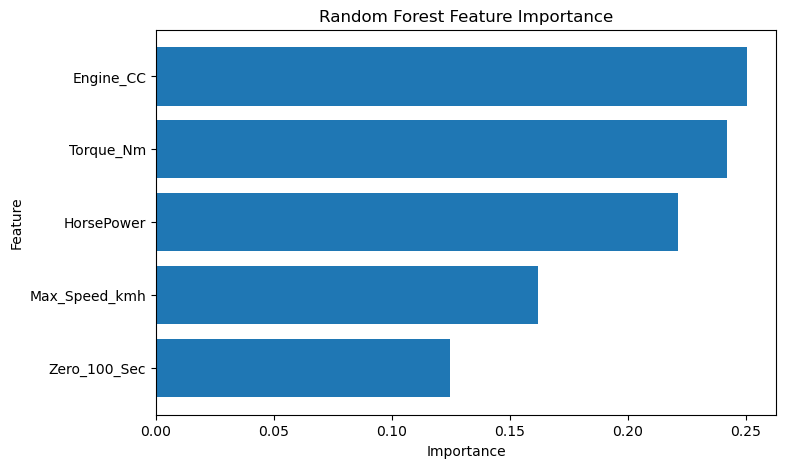

In [ ]:
# Get the feature importances
importances = rf_model.feature_importances_

# Create a DataFrame for better readability
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Print the feature importance DataFrame
print(feature_importance_df)

# Plot the feature importances
plt.figure(figsize=(8,5))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [6]:
# Get the unique labels from test set
labels = sorted(np.unique(np.concatenate([y_test, y_pred])))

# Get original category labels and convert to string list
category_labels = list(y.astype('category').cat.categories)
target_names = list(labels)

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, labels=labels, target_names=target_names))


Classification Report:
               precision    recall  f1-score   support

       Diesel       0.81      0.72      0.76        18
     Electric       1.00      0.95      0.98        22
       Hybrid       0.93      0.46      0.62        28
       Petrol       0.89      0.98      0.93       172
Petrol/Diesel       0.00      0.00      0.00         2

     accuracy                           0.89       242
    macro avg       0.73      0.62      0.66       242
 weighted avg       0.89      0.89      0.88       242

